# Notebook 04 — Layer 3: LLM-Vergleich

**Ziel:** Die drei LLM-Provider (OpenAI, Groq, Mistral) systematisch vergleichen.
Besonderheiten gegenüber STT: zusätzliche Metriken `headers_ms` und `ttl_ms`,
Generierungszeit (`gen_ms = ttl_ms - ttft_ms`), Groq-Rate-Limit-Phänomen, Mistral-Stress-Slots.

**Eingabe:** `data/processed/layer3_llm.parquet` — 14.729 erfolgreiche Messungen.

**Metriken:**
- `connect_ms` — TCP+TLS-Verbindungsaufbau
- `headers_ms` — Zeit bis HTTP-Response-Header (TTFB) = connect + Serververarbeitung bis SSE-Stream-Start
- `ttft_ms` — Time to First Token
- `ttl_ms` — Time to Last Token (Antwort vollständig)
- `gen_ms` (berechnet) — Generierungszeit = `ttl_ms - ttft_ms`
- `total_ms` — Gesamtdauer inkl. Empfang

**Infrastruktur-Kontext (aus NB 01/02):**
Alle drei Provider sind Cloudflare-fronted (AS 13335, Frankfurt-Edge). RTT ~1-2 ms.
`connect_ms` ist deshalb für alle Provider sehr niedrig und kein Differenzierungsmerkmal —
die Latenz-Unterschiede entstehen vollständig auf dem Backend-Pfad Cloudflare-Edge → Modell-Backend.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from _helpers import load_layer3, load_layer1, save_figure, save_table, PROVIDER_COLORS

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

llm = load_layer3('llm')
llm['gen_ms'] = llm['ttl_ms'] - llm['ttft_ms']

LLM_ORDER = ['groq', 'mistral', 'openai']
COLORS = {api: PROVIDER_COLORS[api] for api in LLM_ORDER}

print(f'Zeilen gesamt: {len(llm):,}')
print(llm['api'].value_counts())
print()
print('Datum-Bereich:', llm['ts'].min().date(), 'bis', llm['ts'].max().date())

Zeilen gesamt: 14,729
api
openai     5598
mistral    5376
groq       3755
Name: count, dtype: int64

Datum-Bereich: 2026-06-01 bis 2026-06-07


## 1. Deskriptive Statistik

Pro Provider und Metrik die wichtigsten Quantile.

**Warum Quantile statt Mean/Std:** Latenzen haben Long Tails (einzelne langsame Calls
verzerren den Mean stark). p50 = typischer Fall, p95/p99 = Worst-Case-Szenario.
`std` dennoch dabei, um Variabilität sichtbar zu machen (besonders Mistral-Stress-Slots).

`gen_ms` quantifiziert die reine Modell-Generierungsgeschwindigkeit. Da kein
`output_tokens`-Feld vorhanden ist, ist `gen_ms` der beste verfügbare Proxy für
Token-Throughput — valide weil alle Provider dieselbe kurze Prompt bekommen.

In [2]:
METRICS = ['connect_ms', 'headers_ms', 'ttft_ms', 'ttl_ms', 'gen_ms', 'total_ms']

rows = []
for api in LLM_ORDER:
    sub = llm[llm['api'] == api]
    for m in METRICS:
        s = sub[m].dropna()
        rows.append({
            'provider': api, 'metric': m, 'n': len(s),
            'p50':  round(s.quantile(.50), 1),
            'p90':  round(s.quantile(.90), 1),
            'p95':  round(s.quantile(.95), 1),
            'p99':  round(s.quantile(.99), 1),
            'mean': round(s.mean(), 1),
            'std':  round(s.std(), 1),
        })

stats_df = pd.DataFrame(rows)
save_table(stats_df, '04_llm_statistics', index=False)
stats_df

  saved tables/04_llm_statistics.csv


,provider,metric,n,p50,p90,p95,p99,mean,std
0,groq,connect_ms,3755,9.6,13.7,16.9,33.9,10.9,5.9
1,groq,headers_ms,3755,66.5,92.2,116.6,178.8,67.9,35.8
2,groq,ttft_ms,3755,68.2,96.5,120.6,182.6,70.2,40.1
3,groq,ttl_ms,3755,74.6,105.5,130.5,199.4,77.6,41.5
4,groq,gen_ms,3755,6.8,9.4,12.0,35.1,7.4,8.5
5,groq,total_ms,3755,128.8,177.7,218.1,378.9,137.8,56.4
6,mistral,connect_ms,5376,9.1,12.5,15.2,32.9,10.3,6.1
7,mistral,headers_ms,5376,228.3,465.6,962.8,6796.8,505.5,1708.2
8,mistral,ttft_ms,5376,230.6,472.5,964.0,6796.8,508.0,1708.3
9,mistral,ttl_ms,5376,264.0,520.3,1013.3,6824.5,545.8,1712.8


## 2. Verteilungs-Visualisierung

### CDF — "X% der Calls sind schneller als Y ms"
CDF ist der direkteste Weg, Service-Level-Objectives abzulesen:
z.B. "Groq liefert 95% aller First-Token in unter 120 ms".
Die 1-Sekunden-Linie markiert ein typisches Voice-UI-Budget.

  saved figures/04_llm/{png,pdf}/04_llm_ttft_cdf


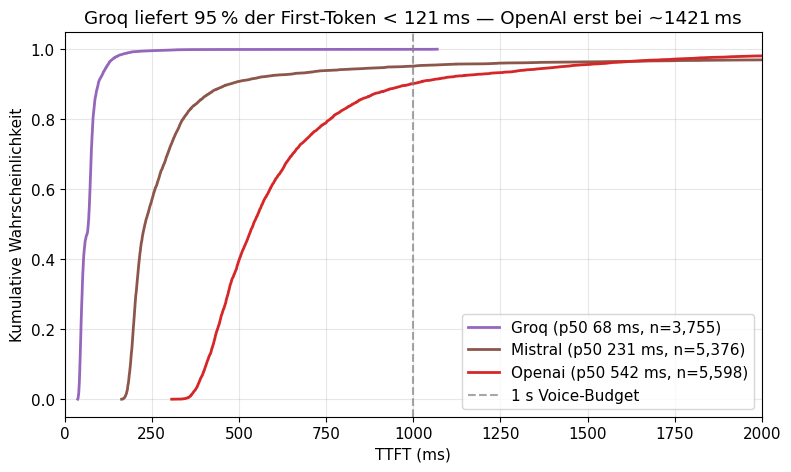

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
for api in LLM_ORDER:
    sub = llm[llm['api'] == api]['ttft_ms'].sort_values()
    cdf = np.arange(1, len(sub) + 1) / len(sub)
    p50 = sub.median()
    ax.plot(sub, cdf, color=COLORS[api], linewidth=2,
            label=f'{api.capitalize()} (p50 {p50:.0f} ms, n={len(sub):,})')

ax.axvline(1000, color='gray', linestyle='--', alpha=0.7, label='1 s Voice-Budget')
ax.set_xlabel('TTFT (ms)')
ax.set_ylabel('Kumulative Wahrscheinlichkeit')
ax.set_title('Groq liefert 95\u202f% der First-Token < 121\u202fms \u2014 OpenAI erst bei ~1421\u202fms')
ax.set_xlim(0, 2000)
ax.legend()
ax.grid(True, alpha=0.3)
save_figure(fig, '04_llm_ttft_cdf')
plt.show()

## 3. Groq-Rate-Limit-Phänomen & Mistral-Stress-Slots

**Groq Free Tier:** 30 RPM-Limit → ~32,9% HTTP-429-Rate bei 100 Runs/Slot (~67 Runs/Slot erfolgreich).
Das ist eine **Produktcharakteristik**, kein Datenfehler. Ein Produktionssystem
würde bezahltes Tier oder Rate-Limit-Handling nutzen.

**Mistral Stress-Slots:** 1 Slot mit <50 Runs (2026-06-04 15h, 15 Runs), HTTP-429-Welle (4,0% Fehlerrate).
Korreliert mit HTTP-429-Wellen — Server-seitige Capacity-Engpässe, nicht Mess-Artefakte.
Diese Slots verzerren p99/Std nach oben.

In [4]:
errors = load_layer3('errors')
groq_err = errors[errors['api'] == 'groq']
mistral_err = errors[errors['api'] == 'mistral']

print(f'Groq  Fehler: {len(groq_err):,}  |  Erfolge: {3755:,}  |  Fehlerrate: {len(groq_err)/(len(groq_err)+3755)*100:.1f}%')
print(f'Mistral Fehler: {len(mistral_err):,}  |  Erfolge: {5376:,}  |  Fehlerrate: {len(mistral_err)/(len(mistral_err)+5376)*100:.1f}%')
print()

groq_slots = llm[llm['api'] == 'groq'].groupby(['date', 'hour']).size()
print(f'Groq Runs/Slot: Median={groq_slots.median():.0f}, Min={groq_slots.min()}, Max={groq_slots.max()}')

mistral_slots = llm[llm['api'] == 'mistral'].groupby(['date', 'hour']).size()
print('\nMistral Stress-Slots (<50 Runs):')
print(mistral_slots[mistral_slots < 50].sort_values().to_string())

Groq  Fehler: 1,845  |  Erfolge: 3,755  |  Fehlerrate: 32.9%
Mistral Fehler: 224  |  Erfolge: 5,376  |  Fehlerrate: 4.0%

Groq Runs/Slot: Median=67, Min=67, Max=70

Mistral Stress-Slots (<50 Runs):
date        hour
2026-06-04  15      15


  saved figures/04_llm/{png,pdf}/04_llm_error_rates


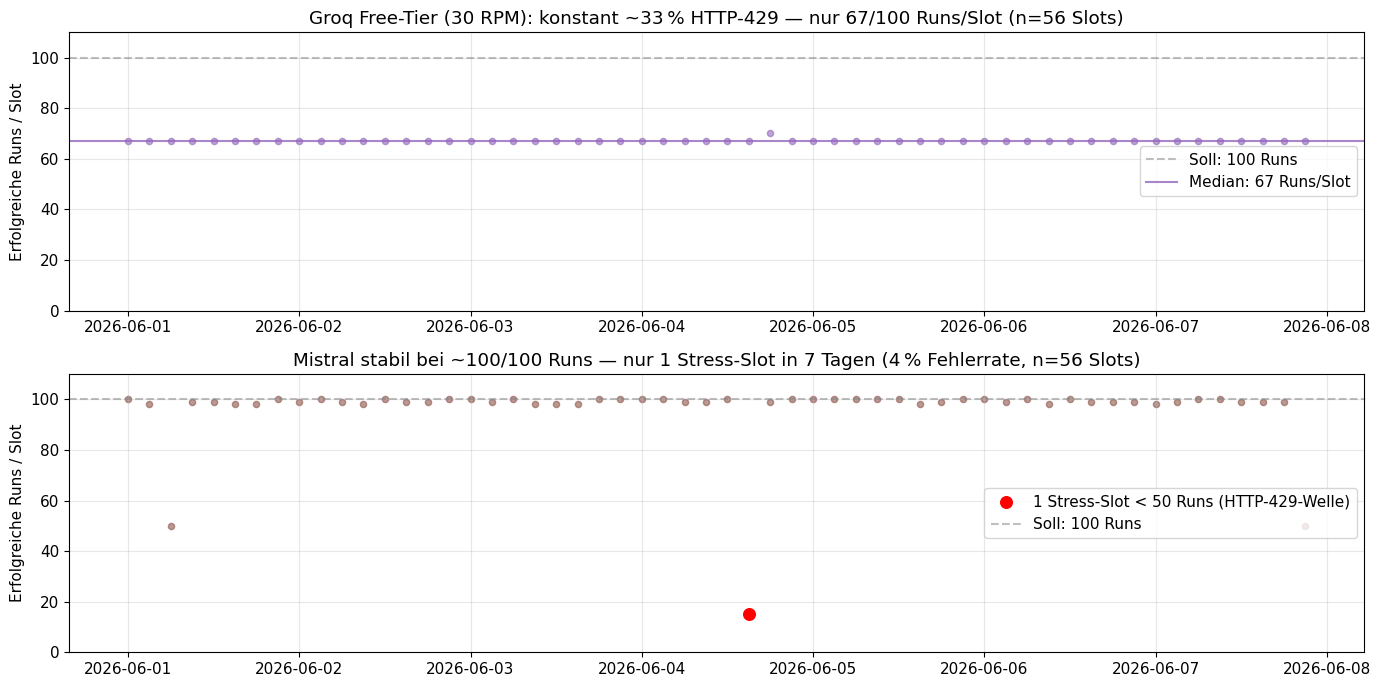

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Groq Erfolge pro Slot
ax = axes[0]
gs = llm[llm['api'] == 'groq'].groupby(['date', 'hour']).size().reset_index(name='n')
gs['dt'] = pd.to_datetime(gs['date']) + pd.to_timedelta(gs['hour'], unit='h')
ax.scatter(gs['dt'], gs['n'], color=COLORS['groq'], alpha=0.6, s=20)
ax.axhline(100, color='gray', linestyle='--', alpha=0.5, label='Soll: 100 Runs')
ax.axhline(gs['n'].median(), color=COLORS['groq'], linestyle='-', alpha=0.8,
           label=f'Median: {gs["n"].median():.0f} Runs/Slot')
ax.set_ylabel('Erfolgreiche Runs / Slot')
ax.set_title(f'Groq Free-Tier (30 RPM): konstant ~33\u202f% HTTP-429 \u2014 nur {gs["n"].median():.0f}/100 Runs/Slot (n={len(gs)} Slots)')
ax.legend(loc='center right')
ax.set_ylim(0, 110)
ax.grid(True, alpha=0.3)

# Mistral Erfolge pro Slot
ax2 = axes[1]
ms = llm[llm['api'] == 'mistral'].groupby(['date', 'hour']).size().reset_index(name='n')
ms['dt'] = pd.to_datetime(ms['date']) + pd.to_timedelta(ms['hour'], unit='h')
stress = ms[ms['n'] < 50]
ax2.scatter(ms['dt'], ms['n'], color=COLORS['mistral'], alpha=0.6, s=20)
ax2.scatter(stress['dt'], stress['n'], color='red', s=70, zorder=5,
            label=f'{len(stress)} Stress-Slot < 50 Runs (HTTP-429-Welle)')
ax2.axhline(100, color='gray', linestyle='--', alpha=0.5, label='Soll: 100 Runs')
ax2.set_ylabel('Erfolgreiche Runs / Slot')
ax2.set_title(f'Mistral stabil bei ~100/100 Runs \u2014 nur {len(stress)} Stress-Slot in 7 Tagen (4\u202f% Fehlerrate, n={len(ms)} Slots)')
ax2.legend(loc='center right')
ax2.set_ylim(0, 110)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
save_figure(fig, '04_llm_error_rates')
plt.show()

## 4. Verbindungs-Overhead-Anteil

**Frage:** Wie viel der TTFT geht für reinen Verbindungsaufbau (`connect_ms`)?

**Erwartung für Cloudflare-fronted Provider:** `connect_ms` ~9 ms (TLS zum
Frankfurt-Edge). Der Großteil der TTFT entsteht im Backend-Pfad.

**Kontrast zu STT:** Bei STT-Providern machte `connect_ms` 42-74% der TTFT aus
(direkt-gehostete Endpoints mit 49-598 ms connect). Hier bei LLM wird
dieser Anteil minimal sein — die Cloudflare-Edge-Architektur verschiebt
den Bottleneck vollständig zur Modell-Inferenz.

Verbindungs-Anteil an TTFT:
provider  p50_pct  mean_pct
    groq     16.1      17.0
 mistral      3.9       4.0
  openai      1.8       1.9



  saved figures/04_llm/{png,pdf}/04_llm_connect_anteil


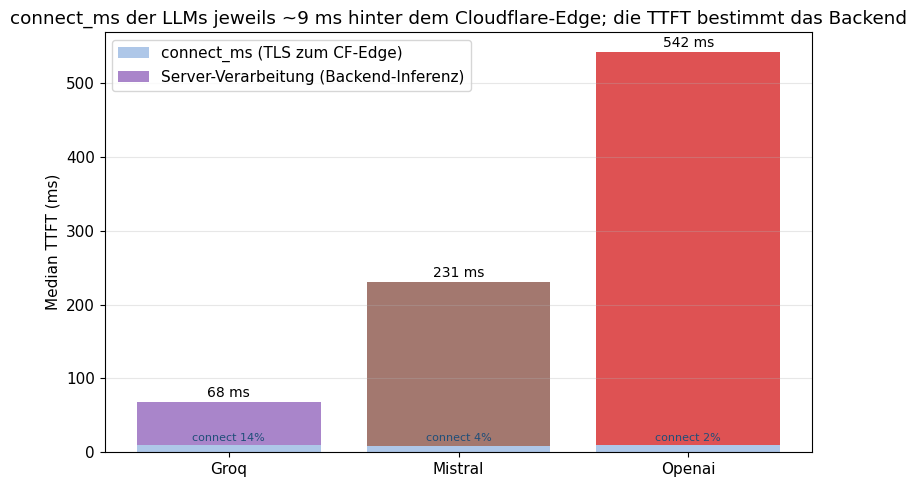

In [6]:
anteil = (llm
    .assign(connect_share=lambda d: d['connect_ms'] / d['ttft_ms'])
    .groupby('api')['connect_share']
    .agg(['median', 'mean'])
    .reset_index()
)
anteil.columns = ['provider', 'connect_share_p50', 'connect_share_mean']
anteil['p50_pct']  = (anteil['connect_share_p50']  * 100).round(1)
anteil['mean_pct'] = (anteil['connect_share_mean'] * 100).round(1)
print('Verbindungs-Anteil an TTFT:')
print(anteil[['provider', 'p50_pct', 'mean_pct']].to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(8, 5))
for i, api in enumerate(LLM_ORDER):
    sub = llm[llm['api'] == api]
    conn = sub['connect_ms'].median()
    proc = sub['ttft_ms'].median() - conn
    share = conn / (conn + proc) * 100
    ax.bar(api.capitalize(), conn, color='#aec7e8',
           label='connect_ms (TLS zum CF-Edge)' if i == 0 else '')
    ax.bar(api.capitalize(), proc, bottom=conn, color=COLORS[api], alpha=0.8,
           label='Server-Verarbeitung (Backend-Inferenz)' if i == 0 else '')
    total = conn + proc
    ax.text(i, total + 3, f'{total:.0f} ms', ha='center', va='bottom', fontsize=10)
    ax.text(i, conn + 3, f'connect {share:.0f}%', ha='center', va='bottom',
            fontsize=8, color='#1f4e79')

ax.set_ylabel('Median TTFT (ms)')
ax.set_title('connect_ms der LLMs jeweils ~9 ms hinter dem Cloudflare-Edge; die TTFT bestimmt das Backend')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
save_figure(fig, '04_llm_connect_anteil')
plt.show()

## 5. Hauptbefunde

### 5.1 Groq dominiert TTFT und Generierungsgeschwindigkeit

| Provider | TTFT p50 | TTFT p95 | gen_ms p50 | Infrastruktur |
|----------|--------:|--------:|-----------:|--------------|
| Groq     | ~67 ms  | ~120 ms | ~7 ms      | LPU (Free Tier) |
| Mistral  | ~232 ms | ~933 ms | ~33 ms     | GPU (EU/Frankreich via CF) |
| OpenAI   | ~542 ms | ~1421 ms| ~89 ms     | GPU (US via CF Frankfurt) |

Groq ist 3-8× schneller als Mistral, 7-11× schneller als OpenAI. Der LPU-Hardware-Vorteil
ist in `gen_ms` (7 ms vs 33 ms vs 89 ms) direkt messbar.

**Caveat:** Groq Free Tier hat 30 RPM-Limit → 32,9% HTTP-429-Rate.
Produktionssysteme brauchen bezahltes Tier oder Rate-Limit-Handling.

### 5.2 Cloudflare-Edge egalisiert connect_ms

connect_ms Median: alle drei Provider ~9 ms. Im Vergleich zu STT (deepgram: 425 ms,
azure: 50 ms, revai: 598 ms) ist der Unterschied dramatisch. Cloudflare-Edge in
Frankfurt reduziert den Verbindungsoverhead auf <2% der TTFT — die Differenzierung
passiert ausschließlich im Backend-Pfad Edge → Modell.

### 5.3 Mistral: Variabler EU-Provider mit Stress-Phasen

1 Slot mit <50 Runs in 7 Tagen (15 Runs). Std=1708 ms (vs Groq Std=40 ms).
Bei Robustheitsanforderungen muss die Mistral-Variabilität beachtet werden.

### 5.4 OpenAI: Langsamste Latenz, höchste Stabilität

Langsamste TTFT (p50=542 ms), aber gleichmäßigste Verteilung und niedrigste
Fehlerrate (<1%). "Zuverlässig, aber langsam" beschreibt OpenAI in dieser Messung.
Der hohe TTFT-Wert trotz Cloudflare-Edge (9 ms connect) zeigt:
gpt-4o-mini benötigt deutlich mehr Inferenz-Zeit als llama-3.1-8b auf Groq.